## Michelle A. Gómez López - 741902
## Simulación de procesos fiancieros

## 11/09/2026
__________

## 1. Simulación de puts y calls

**Parámetros base (los de clase):**

| Parámetro | Valor |
|---|---|
| S₀ (precio del activo) | 100 |
| K (strike) | 100 |
| r (tasa libre de riesgo) | 5% |
| σ (volatilidad) | 20% |
| T (plazo) | 1 año |
| M (número de simulaciones) | 10,000 |

Compara el resultado del precio justo de la opción contra la fórmula de Black-Scholes (ojo: la fórmula para put y para call es diferente).


Se simulan `M = 10,000` trayectorias del precio terminal $S_T$ bajo la medida
neutral al riesgo:

$$S_T = S_0 \cdot \exp\left[\left(r - \tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z\right], \quad Z \sim N(0,1)$$

y se descuenta el payoff esperado:

$$\text{Call} = e^{-rT}\,\mathbb{E}[\max(S_T-K,0)] \qquad \text{Put} = e^{-rT}\,\mathbb{E}[\max(K-S_T,0)]$$

Esto se compara contra la fórmula cerrada de Black-Scholes:

$$d_1 = \frac{\ln(S_0/K) + (r+\tfrac12\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

$$\text{Call}_{BS} = S_0 N(d_1) - K e^{-rT} N(d_2) \qquad \text{Put}_{BS} = K e^{-rT} N(-d_2) - S_0 N(-d_1)$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

SEED = 42
BASE = dict(S0=100.0, K=100.0, r=0.05, sigma=0.20, T=1.0)
M = 10_000

In [2]:
def simulate_mc(S0, K, r, sigma, T, M, seed=SEED):
    # Precio de call y put europeas via Monte Carlo (GBM), con su error estandar.
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(M)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    payoff_call = np.maximum(ST - K, 0)
    payoff_put = np.maximum(K - ST, 0)
    disc = np.exp(-r * T)

    call_price = disc * payoff_call.mean()
    put_price = disc * payoff_put.mean()
    call_se = disc * payoff_call.std(ddof=1) / np.sqrt(M)
    put_se = disc * payoff_put.std(ddof=1) / np.sqrt(M)

    return call_price, put_price, call_se, put_se, ST


def black_scholes(S0, K, r, sigma, T):
    # Precio de call y put europeas via formula cerrada de Black-Scholes.
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    put = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return call, put

In [3]:
call_mc, put_mc, call_se, put_se, ST = simulate_mc(**BASE, M=M, seed=SEED)
call_bs, put_bs = black_scholes(**BASE)

ci_call = (call_mc - 1.96 * call_se, call_mc + 1.96 * call_se)
ci_put = (put_mc - 1.96 * put_se, put_mc + 1.96 * put_se)

resumen_p1 = pd.DataFrame({
    "Monte Carlo": [call_mc, put_mc],
    "Black-Scholes": [call_bs, put_bs],
    "Diferencia": [call_mc - call_bs, put_mc - put_bs],
    "Error estándar (MC)": [call_se, put_se],
    "IC 95% inferior": [ci_call[0], ci_put[0]],
    "IC 95% superior": [ci_call[1], ci_put[1]],
}, index=["Call", "Put"])

print(f"BS dentro del IC 95% de MC -> call: {ci_call[0] <= call_bs <= ci_call[1]}, "
      f"put: {ci_put[0] <= put_bs <= ci_put[1]}")
resumen_p1.round(4)

BS dentro del IC 95% de MC -> call: True, put: True


,Monte Carlo,Black-Scholes,Diferencia,Error estándar (MC),IC 95% inferior,IC 95% superior
Call,10.3452,10.4506,-0.1054,0.1477,10.0558,10.6346
Put,5.6478,5.5735,0.0743,0.0879,5.4756,5.8201


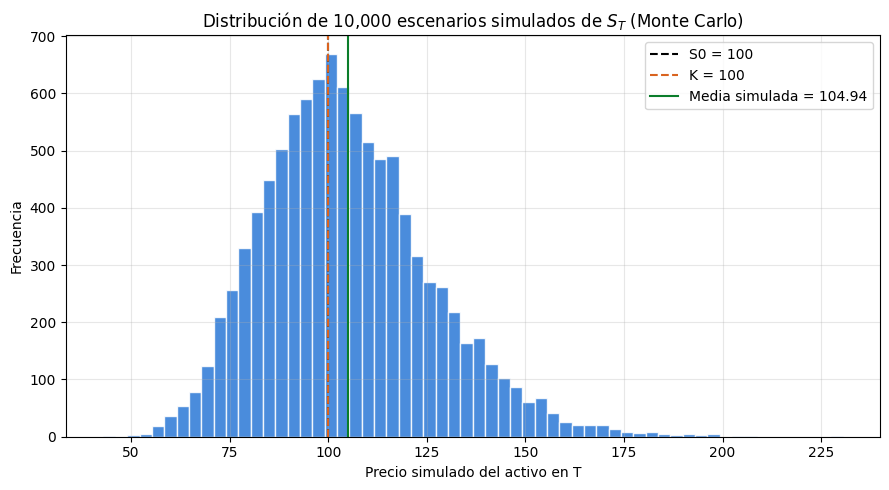

In [4]:
plt.figure(figsize=(9, 5))
plt.hist(ST, bins=60, color="#2a78d6", edgecolor="white", alpha=0.85)
plt.axvline(BASE["S0"], color="black", linestyle="--", linewidth=1.5, label=f"S0 = {BASE['S0']:.0f}")
plt.axvline(BASE["K"], color="#d9631f", linestyle="--", linewidth=1.5, label=f"K = {BASE['K']:.0f}")
plt.axvline(ST.mean(), color="#0a7d2a", linewidth=1.5, label=f"Media simulada = {ST.mean():.2f}")
plt.title(f"Distribución de {M:,} escenarios simulados de $S_T$ (Monte Carlo)")
plt.xlabel("Precio simulado del activo en T")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Sensibilidad
Varía un parámetro a la vez:

- Precio del activo (80, 90, 100, 110, 120)

- Strike (80, 90, 100, 110, 120)

- Volatilidad (10%, 20%, 30%, 40%, 50%)

- Tiempo (0.25, 0.5, 1, 1.5, 2)

- Rendimiento (5%, 10%, 15%, 20%)

In [5]:
SWEEPS = {
    "S0":    dict(values=[80, 90, 100, 110, 120],        label="Precio del activo (S0)"),
    "K":     dict(values=[80, 90, 100, 110, 120],        label="Strike (K)"),
    "sigma": dict(values=[0.10, 0.20, 0.30, 0.40, 0.50], label="Volatilidad (sigma)"),
    "T":     dict(values=[0.25, 0.5, 1, 1.5, 2],         label="Tiempo a vencimiento (T, años)"),
    "r":     dict(values=[0.05, 0.10, 0.15, 0.20],       label="Tasa libre de riesgo (r)"),
}


def run_sweeps():
    results = {}
    for param, cfg in SWEEPS.items():
        rows = []
        for v in cfg["values"]:
            params = dict(BASE)
            params[param] = v
            c_mc, p_mc, c_se, p_se, _ = simulate_mc(**params, M=M, seed=SEED)
            c_bs, p_bs = black_scholes(**params)
            rows.append(dict(valor=v, call_mc=c_mc, put_mc=p_mc, call_bs=c_bs, put_bs=p_bs))
        results[param] = pd.DataFrame(rows)
    return results


sweep_results = run_sweeps()

In [6]:
for param, df in sweep_results.items():
    print(f"\n--- {SWEEPS[param]['label']} ---")
    display(df.round(4))


--- Precio del activo (S0) ---


,valor,call_mc,put_mc,call_bs,put_bs
0,80,1.8712,17.1379,1.8594,16.9824
1,90,5.0420,10.3267,5.0912,10.2142
2,100,10.3452,5.6478,10.4506,5.5735
3,110,17.5468,2.8674,17.6630,2.7859
4,120,26.0162,1.3548,26.1690,1.2920



--- Strike (K) ---


,valor,call_mc,put_mc,call_bs,put_bs
0,80,24.4485,0.7266,24.5888,0.6872
1,90,16.5930,2.3833,16.6994,2.3101
2,100,10.3452,5.6478,10.4506,5.5735
3,110,5.9824,10.7973,6.0401,10.6753
4,120,3.2382,17.5655,3.2475,17.3950



--- Volatilidad (sigma) ---


,valor,call_mc,put_mc,call_bs,put_bs
0,0.1,6.7516,1.9707,6.8050,1.9279
1,0.2,10.3452,5.6478,10.4506,5.5735
2,0.3,14.0879,9.4610,14.2313,9.3542
3,0.4,17.8618,13.2915,18.0230,13.1459
4,0.5,21.6259,17.0969,21.7926,16.9155



--- Tiempo a vencimiento (T, años) ---


,valor,call_mc,put_mc,call_bs,put_bs
0,0.25,4.5643,3.4182,4.6150,3.3728
1,0.50,6.8157,4.4790,6.8887,4.4197
2,1.00,10.3452,5.6478,10.4506,5.5735
3,1.50,13.3118,6.2992,13.4429,6.2173
4,2.00,15.9759,6.6987,16.1268,6.6105



--- Tasa libre de riesgo (r) ---


,valor,call_mc,put_mc,call_bs,put_bs
0,0.05,10.3452,5.6478,10.4506,5.5735
1,0.10,13.1625,3.8260,13.2697,3.7534
2,0.15,16.2499,2.5004,16.3560,2.4268
3,0.20,19.5167,1.5695,19.6299,1.5030


## 3. Visualización

Generar una gráfica con dos líneas (una para call y otra para put) por parámetro variado

- Precio de la opción vs precio del activo

- Precio de la opción vs strike

- Precio de la opción vs volatilidad

- Precio de la opción vs tiempo

- Precio de la opción vs rendimiento

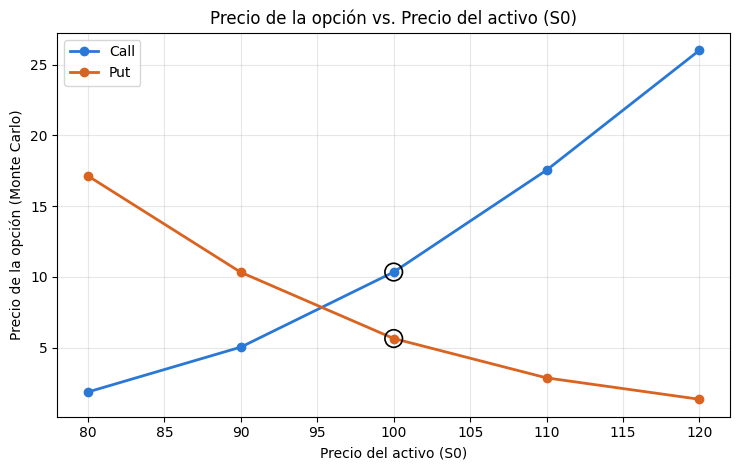

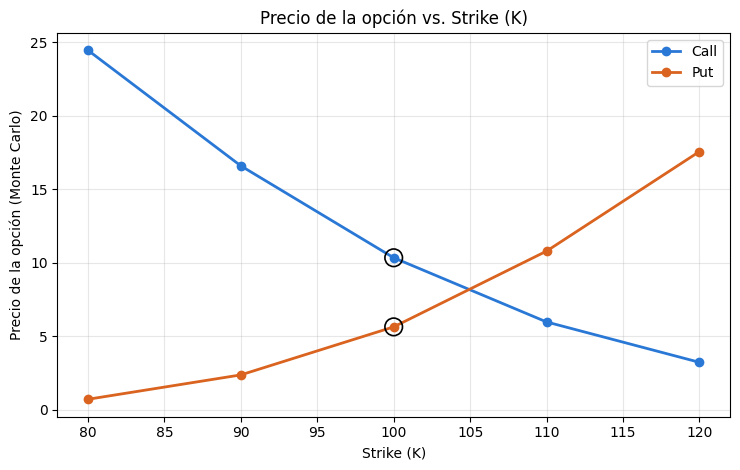

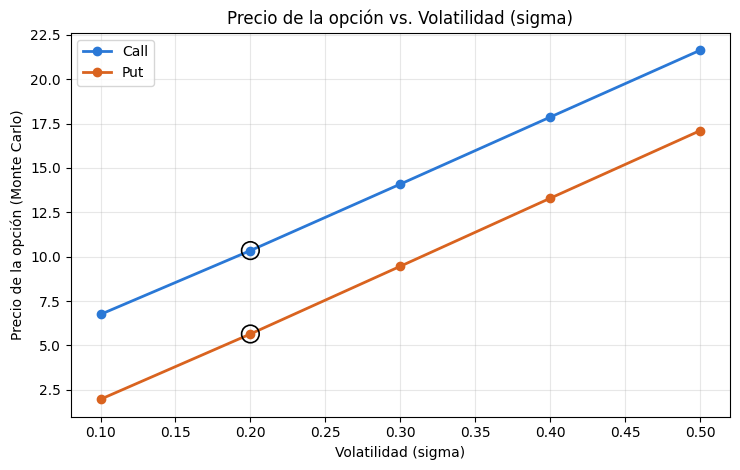

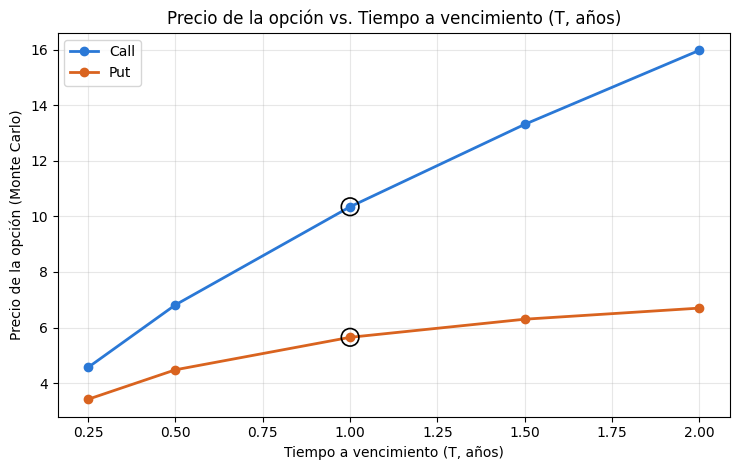

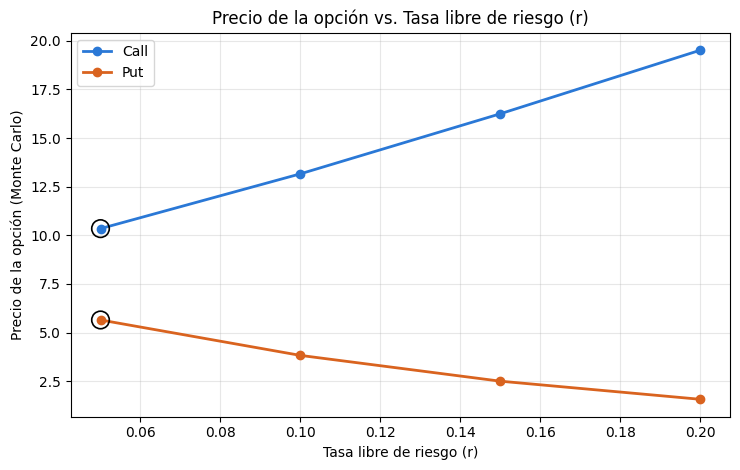

In [7]:
def plot_sweep(param):
    cfg = SWEEPS[param]
    df = sweep_results[param]
    base_val = BASE[param]

    plt.figure(figsize=(7.5, 4.8))
    plt.plot(df["valor"], df["call_mc"], marker="o", color="#2a78d6", linewidth=2, label="Call")
    plt.plot(df["valor"], df["put_mc"], marker="o", color="#d9631f", linewidth=2, label="Put")

    base_row = df[np.isclose(df["valor"], base_val)]
    if not base_row.empty:
        plt.scatter(base_row["valor"], base_row["call_mc"], s=160, facecolors="none",
                    edgecolors="black", linewidths=1.2, zorder=5)
        plt.scatter(base_row["valor"], base_row["put_mc"], s=160, facecolors="none",
                    edgecolors="black", linewidths=1.2, zorder=5)

    plt.title(f"Precio de la opción vs. {cfg['label']}")
    plt.xlabel(cfg["label"])
    plt.ylabel("Precio de la opción (Monte Carlo)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"sensibilidad_{param}.png", dpi=150)
    plt.show()


for param in SWEEPS:
    plot_sweep(param)

## 4. Interpretación

*Precio del activo*

¿Por qué una call aumenta cuando aumenta el precio de la acción?

El payoff de la call es max(S_T − K, 0): cada peso que S₀ sube se traslada, en expectativa, a un peso adicional de ganancia al vencimiento, mientras que la pérdida máxima queda acotada a la prima. En el barrido de S₀ (80→120) la call pasa de 1.86 a 26.17 (BS): su valor crece de forma monótona y convexa porque combina mayor probabilidad de terminar in‑the‑money con mayor magnitud del payoff cuando eso ocurre.

¿Por qué una put se comporta de manera distinta?

La put paga max(K − S_T, 0): es un seguro contra caídas, así que gana valor cuando el activo vale menos, no más. En el mismo barrido la put cae de 16.98 a 1.29 — exactamente el patrón inverso de la call, porque ambas opciones apuestan a lados opuestos del mismo subyacente.
____

*Volatilidad*

¿Por qué una mayor incertidumbre aumenta o disminuye el valor de la opción?

Siempre lo aumenta, para call y para put. La razón no es direccional sino de forma del payoff: ambas opciones tienen pérdida acotada (la prima) y ganancia potencialmente grande. Subir σ ensancha la distribución de S_T sin mover su media neutral al riesgo (S₀·e^(rT)), lo que agranda la cola favorable sin empeorar la cola desfavorable —el tenedor nunca pierde más que lo que ya pagó—. Por eso en el barrido de σ (10%→50%) ambas primas suben: la call de 6.80 a 21.79 (+220%) y la put de 1.93 a 16.92 (+775%): la put, al partir de un valor mucho más pequeño, es proporcionalmente la más sensible a la volatilidad.
____
*Tiempo*

¿Siempre es deseable tener más tiempo?

Para la call sí: en el barrido de T (0.25→2) sube de forma monótona de 4.61 a 16.13, porque más tiempo siempre significa más varianza acumulada en S_T y, además, un pago de K más lejano cuyo valor presente es menor. Ambos efectos favorecen a la call.

Para la put el resultado es la superposición de dos fuerzas que compiten: más tiempo también añade optionalidad (bueno para la put), pero además descuenta más el strike que el tenedor "recibiría" al ejercer (malo para la put, porque reduce su valor presente). En nuestra corrida (r=5%) domina el primer efecto y la put también sube, de 3.37 a 6.61. Sin embargo esto no es una ley general: con una tasa r suficientemente alta y una put muy in‑the‑money, el efecto del descuento puede dominar y el valor de la put puede empezar a caer con más tiempo a vencimiento —algo que nunca le ocurre a una call europea sobre un activo sin dividendos—.


¿Para quién resulta favorable?

Hay que distinguir dos preguntas. La que simulamos aquí compara, en el instante inicial, opciones con distinto plazo total: ahí, tener acceso a más tiempo casi siempre encarece la opción (más valor para quien la compra desde cero). La otra pregunta —qué le pasa al valor de una opción ya comprada, a S y σ fijos, simplemente por el paso de los días (theta)— normalmente juega en contra del comprador: el tiempo que se agota erosiona el valor de la opción, lo cual favorece a quien la vendió (escribió) y cobró la prima por adelantado.
____

*Strike*

¿Cómo modifica el strike la probabilidad de termina in-the-money?

Bajo el modelo, la probabilidad neutral al riesgo de que la call termine in‑the‑money es N(d₂), y la de la put es N(−d₂); d₂ cae cuando K sube. Por eso, al mover K de 80 a 120, la call pierde probabilidad de éxito y su precio cae de 24.59 a 3.25, mientras que la put gana probabilidad de éxito y sube de 0.69 a 17.40: subir el strike es, en esencia, mover el "umbral de la apuesta" en contra de la call y a favor de la put.

Definir in-the-money

Una opción está in‑the‑money (ITM) si se ejercería hoy con ganancia bruta: una call cuando S > K, una put cuando S < K. Está at‑the‑money (ATM) cuando S ≈ K, y out‑of‑the‑money (OTM) cuando ejercerla hoy no generaría ganancia (S < K para la call, S > K para la put) — en ese caso el tenedor simplemente la deja expirar y el payoff es cero.

## 4. Comparación con el mercado
Si fueras un inversionista, ¿cuál parámetro consideras más importante monitorear? ¿Por qué? Justifica usando tus resultados


La **volatilidad**. No es solo el más sensible de los cinco en nuestros resultados, sino el único que combina alta sensibilidad con alta incertidumbre real. S₀ y K definen el contrato (K es fijo; S₀ se observa en tiempo real, no hay que estimarlo); T se conoce con certeza; r se mueve lentamente y en rangos acotados —de hecho, en el barrido de r (5%→20%, un salto de 15 puntos porcentuales que casi nunca ocurre en la vida de una sola opción) la call sube 88% y la put cae 73%, un movimiento grande pero producido por un cambio de tasa que es poco realista en la práctica—.

La volatilidad, en cambio, no se observa directamente: hay que inferirla (volatilidad implícita) y puede cambiar de forma abrupta con noticias, resultados trimestrales o estrés de mercado, incluso sin que S₀ se mueva. En nuestro barrido, subir σ de 10% a 50% —un rango que sí es realista entre una acción tranquila y una muy volátil— casi cuadruplica el precio de la call (6.80→21.79) y multiplica por 8.8 el de la put (1.93→16.92): es el parámetro con mayor "vega risk" y, por ser el único que el mercado repriza constantemente sin previo aviso, el que un inversionista en opciones debería vigilar más de cerca.